In [13]:
!pip install pandas numpy matplotlib seaborn plotly statsmodels prophet xgboost scikit-learn pmdarima --quiet

**SetUp**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')


In [15]:
import os

base_path = r"C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita"
os.makedirs(base_path, exist_ok=True)
os.makedirs(os.path.join(base_path, "charts"), exist_ok=True)

os.chdir(base_path)
print("Working directory is now:", os.getcwd())
print("Contents:", os.listdir(base_path))

Working directory is now: C:\Users\Pranita Kumbhar\Downloads\SalesForecasting_Pranita
Contents: ['app.py', 'charts', 'train.csv', 'Untitled14.ipynb', 'vgsales.csv']


In [54]:
project_path = r"C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita"
with open(os.path.join(project_path, "requirements.txt"), "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn
plotly
statsmodels
prophet
pmdarima
xgboost
scikit-learn
streamlit
""")

print("requirements.txt written to:", os.path.join(project_path, "requirements.txt"))

requirements.txt written to: C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita\requirements.txt


**TASK 1 — Data Loading, Merging & Deep Exploration**

In [16]:
df = pd.read_csv("C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita/train.csv", encoding='latin1')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [17]:
# Parse dates - your file is DD/MM/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [18]:
# Time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
df['Season'] = df['Month'].apply(get_season)

df[['Order Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season']].head()

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


In [19]:
# Missing values, duplicates, dtype check

print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64

Duplicate rows: 0

Dtypes:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category     

In [20]:
# Weekly and Monthly aggregation

df.set_index('Order Date', inplace=True)

weekly_sales = df['Sales'].resample('W').sum().reset_index()
monthly_sales = df['Sales'].resample('M').sum().reset_index()

df.reset_index(inplace=True)

print(weekly_sales.head())
print(monthly_sales.head())

  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


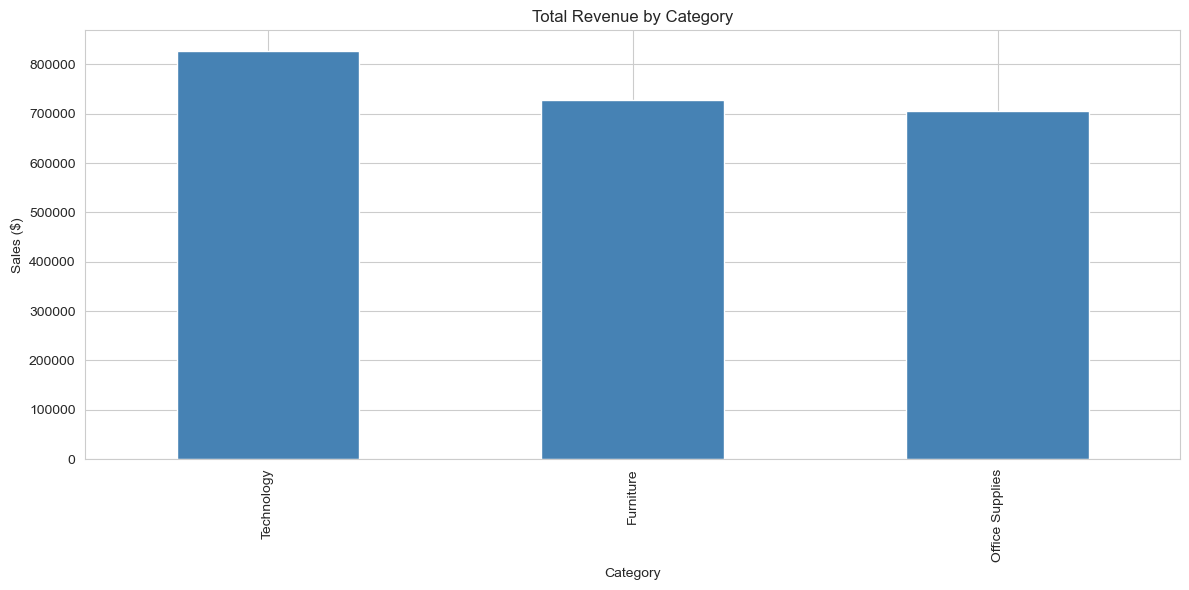

In [21]:
# Q1: Category with highest revenue

cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

cat_revenue.plot(kind='bar', title='Total Revenue by Category', color='steelblue')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png')
plt.show()

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Coefficient of variation of YoY growth (lower = more consistent):
Region
East       0.099209
West       1.204981
Central    1.951359
South      3.494317
dtype: float64


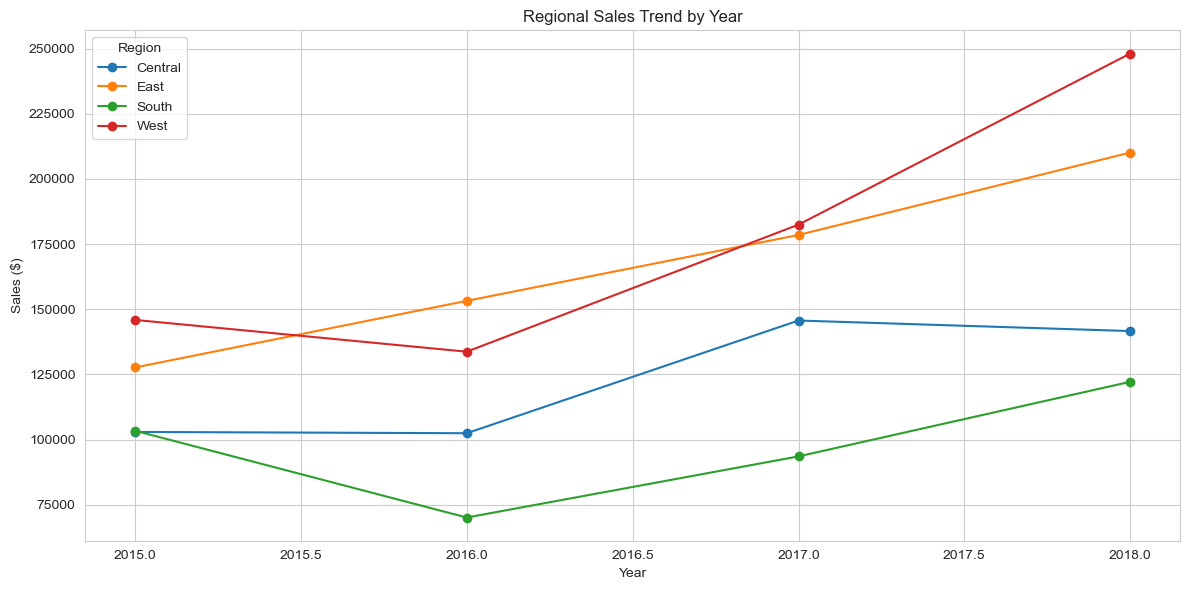

In [11]:
# Q2: Region with most consistent growth

region_year = df.groupby(['Region','Year'])['Sales'].sum().reset_index()
pivot = region_year.pivot(index='Year', columns='Region', values='Sales')
print(pivot)

# consistency = low coefficient of variation of YoY growth
growth = pivot.pct_change().dropna()
cv = growth.std() / growth.mean().abs()
print("\nCoefficient of variation of YoY growth (lower = more consistent):")
print(cv.sort_values())

pivot.plot(marker='o', title='Regional Sales Trend by Year')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/region_trend.png')
plt.show()

In [22]:
# Q3: Avg shipping time, does it vary by region?

df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Overall average shipping time:", df['ShipDays'].mean(), "days")
print("\nBy Region:\n", df.groupby('Region')['ShipDays'].mean().sort_values())

Overall average shipping time: 3.9611224489795918 days

By Region:
 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDays, dtype: float64


Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


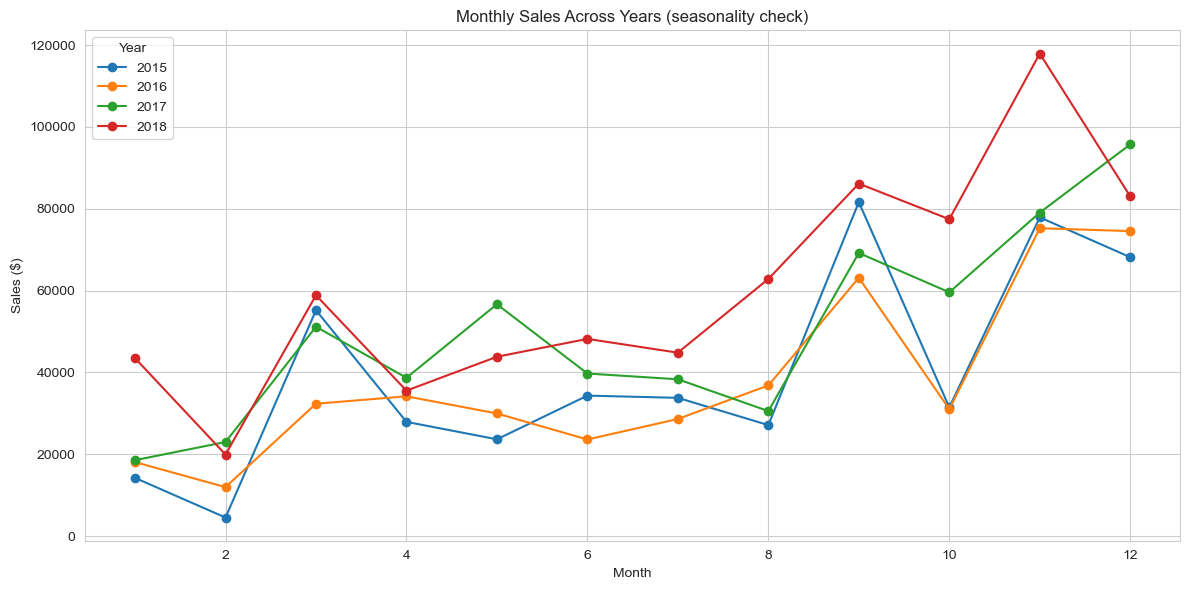


Average sales by month (highest = strongest seasonal peak):
Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
dtype: float64


In [23]:
# Q4: Seasonality - months that spike across all years

monthly_by_year = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
pivot2 = monthly_by_year.pivot(index='Month', columns='Year', values='Sales')
print(pivot2)

pivot2.plot(marker='o', title='Monthly Sales Across Years (seasonality check)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png')
plt.show()

print("\nAverage sales by month (highest = strongest seasonal peak):")
print(pivot2.mean(axis=1).sort_values(ascending=False))

**TASK 2 — Time Series Decomposition**

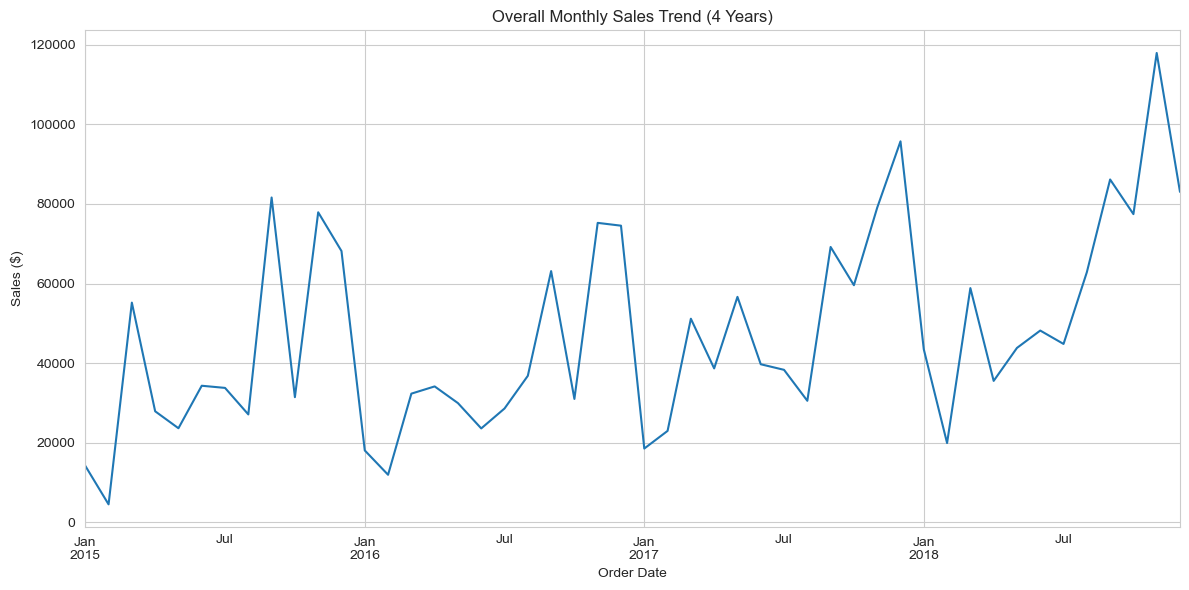

In [24]:
monthly_sales_idx = monthly_sales.set_index('Order Date')['Sales']

monthly_sales_idx.plot(title='Overall Monthly Sales Trend (4 Years)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_trend.png')
plt.show()

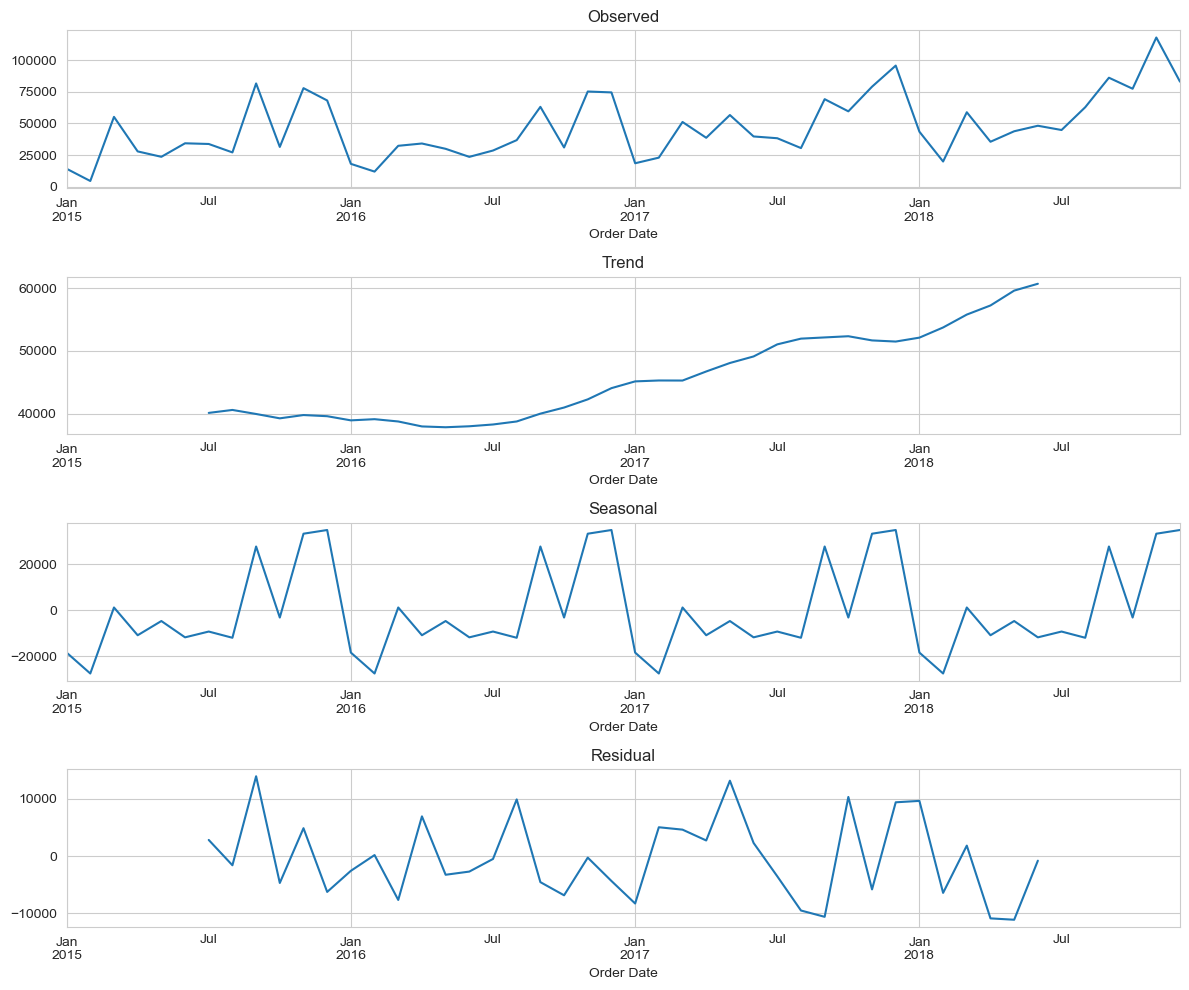

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales_idx, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('charts/decomposition.png')
plt.show()

In [26]:
# ADF stationarity test

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales_idx.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:', result[4])

if result[1] < 0.05:
    print("\n=> Series IS stationary (reject null hypothesis)")
else:
    print("\n=> Series is NOT stationary (fail to reject null hypothesis)")

ADF Statistic: -4.4161
p-value: 0.0003
Critical Values: {'1%': -3.5778480370438146, '5%': -2.925338105429433, '10%': -2.6007735310095064}

=> Series IS stationary (reject null hypothesis)


ADF Statistic (differenced): -8.7271
p-value (differenced): 0.0000


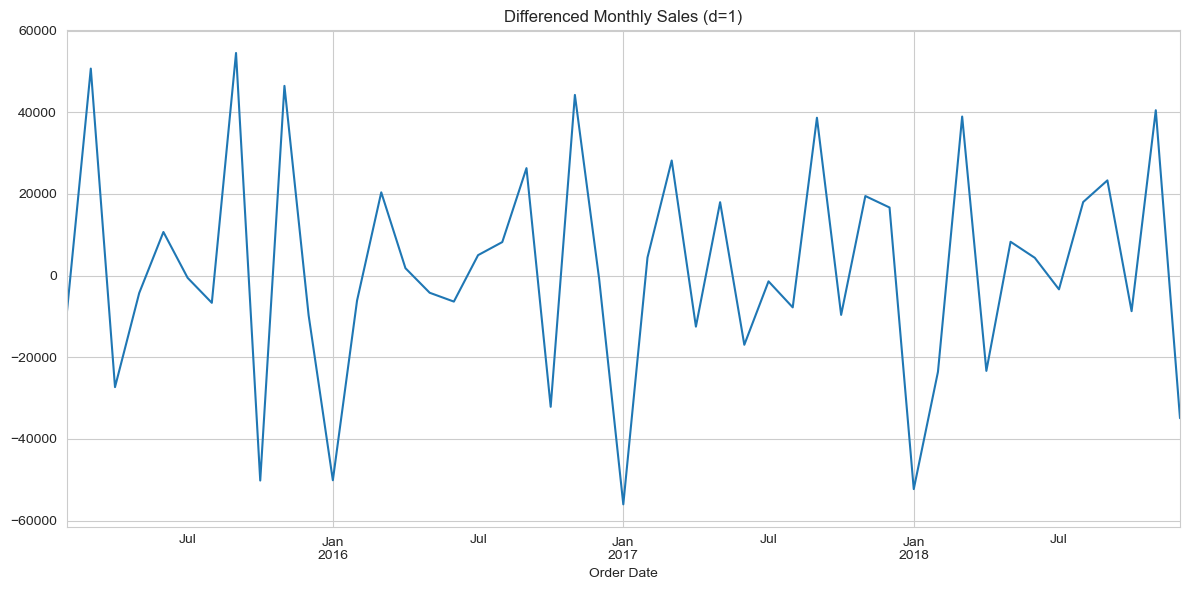

In [27]:
# Differencing if non-stationary

monthly_diff = monthly_sales_idx.diff().dropna()

result_diff = adfuller(monthly_diff)
print(f'ADF Statistic (differenced): {result_diff[0]:.4f}')
print(f'p-value (differenced): {result_diff[1]:.4f}')

monthly_diff.plot(title='Differenced Monthly Sales (d=1)')
plt.tight_layout()
plt.savefig('charts/differenced_series.png')
plt.show()

**TASK 3 — Three Forecasting Models**

In [28]:
# Train/test split - hold out last 3 months

train_data = monthly_sales_idx.iloc[:-3]
test_data = monthly_sales_idx.iloc[-3:]
print(train_data.shape, test_data.shape)

(45,) (3,)


**Model 1 — SARIMA**

In [29]:
import pmdarima as pm

auto_model = pm.auto_arima(train_data, seasonal=True, m=12,
                            trace=True, suppress_warnings=True,
                            stepwise=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1009.640, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1025.765, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1007.450, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1007.755, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1023.942, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1020.706, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1009.338, Time=0.23 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1009.427, Time=0.09 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1011.652, Time=0.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1011.126, Time=0.36 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1012.838, Time=0.06 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1004.192, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1017.580, Time=0.05 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1005.949, Time=0.25 sec
 ARIMA(2,1,0)(1,0,1

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_data.index.freq = 'M'
test_data.index.freq = 'M'

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print("Chosen order:", order, "seasonal_order:", seasonal_order)

sarima_model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

print(sarima_pred)
print(sarima_ci)

Chosen order: (2, 1, 0) seasonal_order: (1, 0, 0, 12)
2018-10-31     73694.383142
2018-11-30     95396.628124
2018-12-31    107210.620330
Freq: ME, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2018-10-31  50130.352393   97258.413892
2018-11-30  69984.996110  120808.260137
2018-12-31  80340.261591  134080.979068


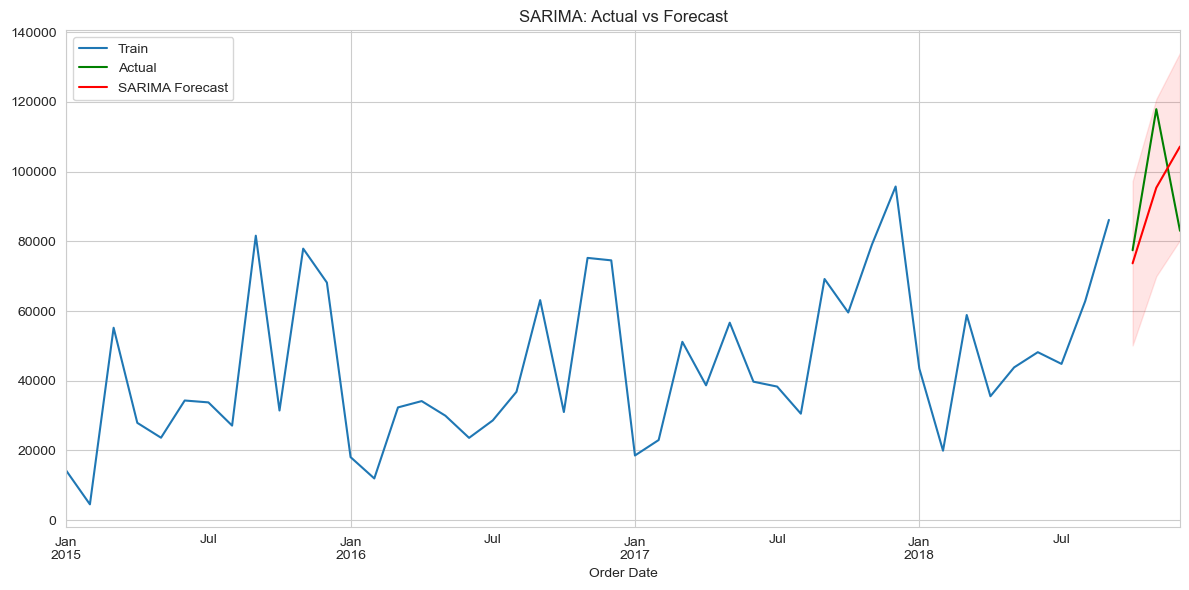

In [31]:
plt.figure()
train_data.plot(label='Train')
test_data.plot(label='Actual', color='green')
sarima_pred.plot(label='SARIMA Forecast', color='red')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='red', alpha=0.1)
plt.legend()
plt.title('SARIMA: Actual vs Forecast')
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png')
plt.show()

**Model 2 — Prophet**

14:38:55 - cmdstanpy - INFO - Chain [1] start processing
14:38:57 - cmdstanpy - INFO - Chain [1] done processing


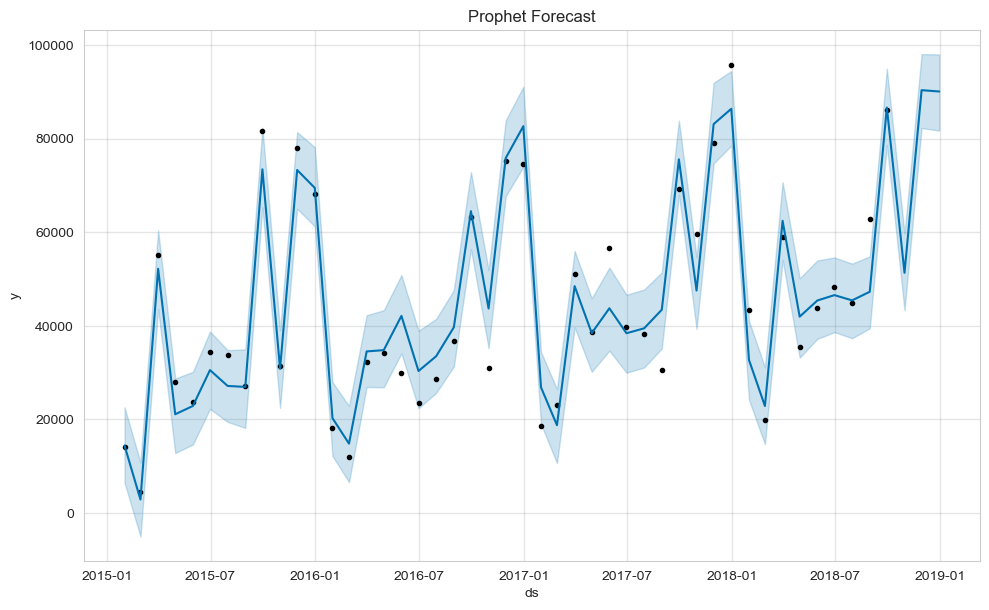

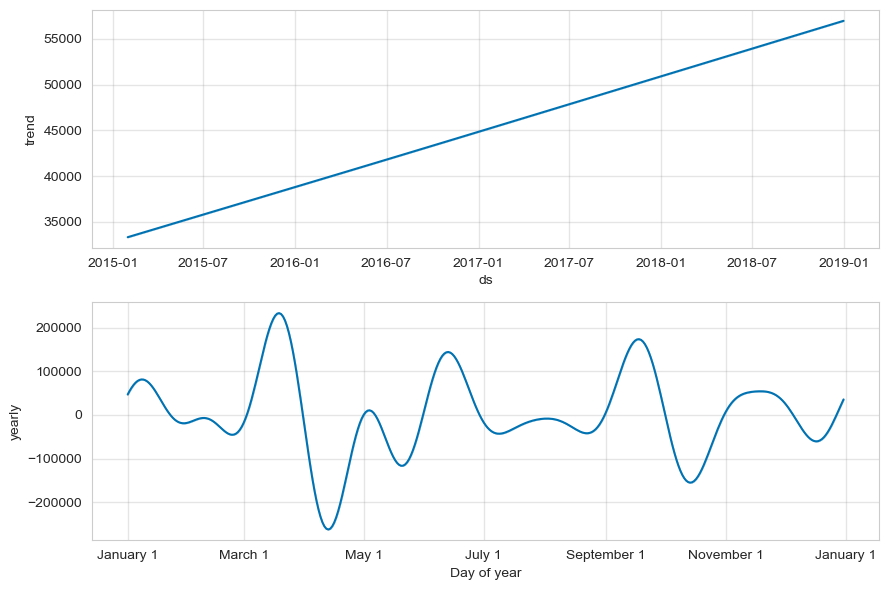

In [32]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

from prophet import Prophet

prophet_df = monthly_sales.rename(columns={'Order Date':'ds', 'Sales':'y'})
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='M')
prophet_forecast = prophet_model.predict(future)

fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.savefig('charts/prophet_forecast.png')
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig('charts/prophet_components.png')
plt.show()

In [33]:
prophet_pred = prophet_forecast[['ds','yhat']].tail(3).set_index('ds')['yhat']
print(prophet_pred)

ds
2018-10-31    51318.943858
2018-11-30    90325.654784
2018-12-31    90041.084479
Name: yhat, dtype: float64


**Model 3 — XGBoost**

In [34]:
from xgboost import XGBRegressor

xgb_df = monthly_sales.copy()
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)
xgb_df['RollingMean3'] = xgb_df['Sales'].shift(1).rolling(3).mean()
xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter
xgb_df['Season'] = xgb_df['Month'].apply(get_season)
xgb_df = pd.get_dummies(xgb_df, columns=['Season'])
xgb_df.dropna(inplace=True)

feature_cols = [c for c in xgb_df.columns if c not in ['Order Date','Sales']]
X = xgb_df[feature_cols]
y = xgb_df['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(xgb_pred)

[67994.234 87716.29  66889.15 ]


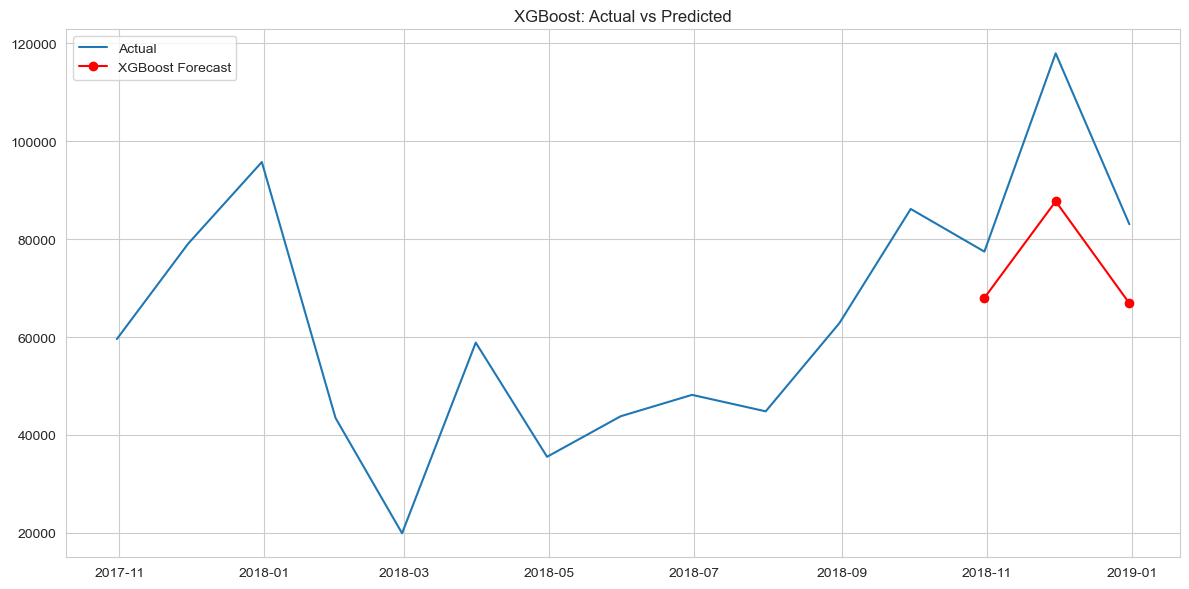

In [35]:
plt.figure()
plt.plot(xgb_df['Order Date'].iloc[-15:], xgb_df['Sales'].iloc[-15:], label='Actual')
plt.plot(xgb_df['Order Date'].iloc[-3:], xgb_pred, label='XGBoost Forecast', marker='o', color='red')
plt.legend()
plt.title('XGBoost: Actual vs Predicted')
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png')
plt.show()

**Model Comparison Table**

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [
        mean_absolute_error(test_data, sarima_pred),
        mean_absolute_error(prophet_test['y'].values, prophet_pred.values),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(test_data, sarima_pred)),
        np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_pred.values)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'MAPE': [
        mape(test_data.values, sarima_pred.values),
        mape(prophet_test['y'].values, prophet_pred.values),
        mape(y_test.values, xgb_pred)
    ],
    'Forecast_M1': [sarima_pred.iloc[0], prophet_pred.iloc[0], xgb_pred[0]],
    'Forecast_M2': [sarima_pred.iloc[1], prophet_pred.iloc[1], xgb_pred[1]],
    'Forecast_M3': [sarima_pred.iloc[2], prophet_pred.iloc[2], xgb_pred[2]],
})
results

,Model,MAE,RMSE,MAPE,Forecast_M1,Forecast_M2,Forecast_M3
0,SARIMA,16825.168821,19208.458685,17.693981,73694.383142,95396.628124,107210.620330
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,18605.667708,20520.534320,19.090696,67994.234375,87716.289062,66889.148438


**TASK 4 — Category & Region Level Forecasting**

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def prepare_and_forecast_sarima(sub_df, label, order, seasonal_order):
    ts = sub_df.set_index('Order Date')['Sales'].resample('M').sum()
    ts.index.freq = 'M'

    train = ts.iloc[:-3]

    model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)

    forecast = fit.get_forecast(steps=3)
    pred = forecast.predicted_mean

    return ts, pred, label

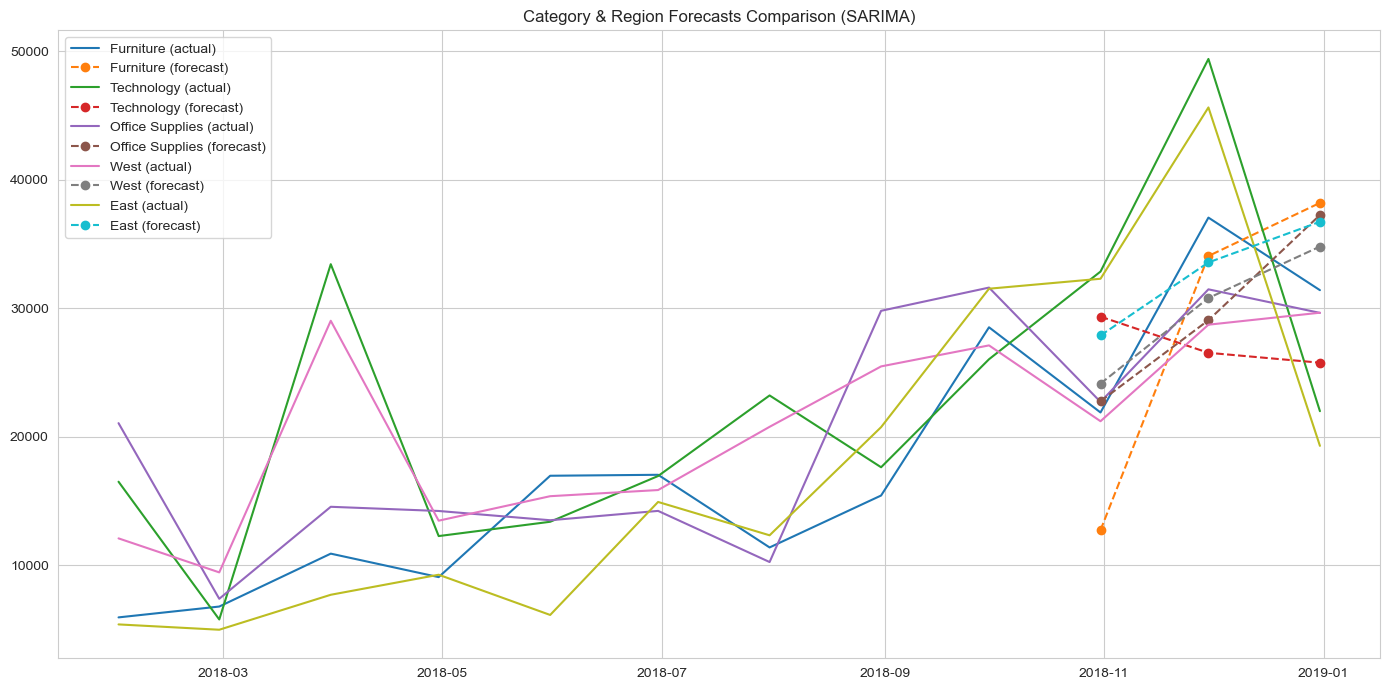

Furniture :
2018-10-31    12723.865036
2018-11-30    34065.747550
2018-12-31    38203.047911
Freq: ME, Name: predicted_mean, dtype: float64

Technology :
2018-10-31    29345.655087
2018-11-30    26530.543205
2018-12-31    25759.577576
Freq: ME, Name: predicted_mean, dtype: float64

Office Supplies :
2018-10-31    22755.924918
2018-11-30    29066.493845
2018-12-31    37256.942737
Freq: ME, Name: predicted_mean, dtype: float64

West :
2018-10-31    24133.200331
2018-11-30    30793.293152
2018-12-31    34801.757885
Freq: ME, Name: predicted_mean, dtype: float64

East :
2018-10-31    27878.295844
2018-11-30    33565.816922
2018-12-31    36731.743473
Freq: ME, Name: predicted_mean, dtype: float64



In [39]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order

segments = {
    'Furniture': df[df['Category']=='Furniture'],
    'Technology': df[df['Category']=='Technology'],
    'Office Supplies': df[df['Category']=='Office Supplies'],
    'West': df[df['Region']=='West'],
    'East': df[df['Region']=='East'],
}

plt.figure(figsize=(14,7))
segment_results = {}

for label, sub_df in segments.items():
    try:
        ts, pred, _ = prepare_and_forecast_sarima(sub_df, label, order, seasonal_order)
    except Exception as e:
        print(f"{label} failed with chosen order, retrying with simpler order (1,1,1)x(0,0,0,12): {e}")
        ts, pred, _ = prepare_and_forecast_sarima(sub_df, label, (1,1,1), (0,0,0,12))

    segment_results[label] = pred

    plt.plot(ts.index[-12:], ts.values[-12:], label=f'{label} (actual)')
    plt.plot(pred.index, pred.values, linestyle='--', marker='o', label=f'{label} (forecast)')

plt.legend()
plt.title('Category & Region Forecasts Comparison (SARIMA)')
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png')
plt.show()

for label, pred in segment_results.items():
    print(label, ':')
    print(pred)
    print()

In [40]:
for label, pred in segment_results.items():
    growth_pct = (pred.iloc[-1] - pred.iloc[0]) / pred.iloc[0] * 100
    print(f"{label}: {growth_pct:.1f}% growth Month1 -> Month3")

Furniture: 200.2% growth Month1 -> Month3
Technology: -12.2% growth Month1 -> Month3
Office Supplies: 63.7% growth Month1 -> Month3
West: 44.2% growth Month1 -> Month3
East: 31.8% growth Month1 -> Month3


**TASK 5 — Anomaly Detection**

In [44]:
vg = pd.read_csv("C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita/vgsales.csv")
vg.head()

vg_yearly = vg.groupby('Year')['Global_Sales'].sum().reset_index()
superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()

merged_practice = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner',
                            suffixes=('_superstore','_videogames'))
merged_practice

,Year,Sales,Global_Sales
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05


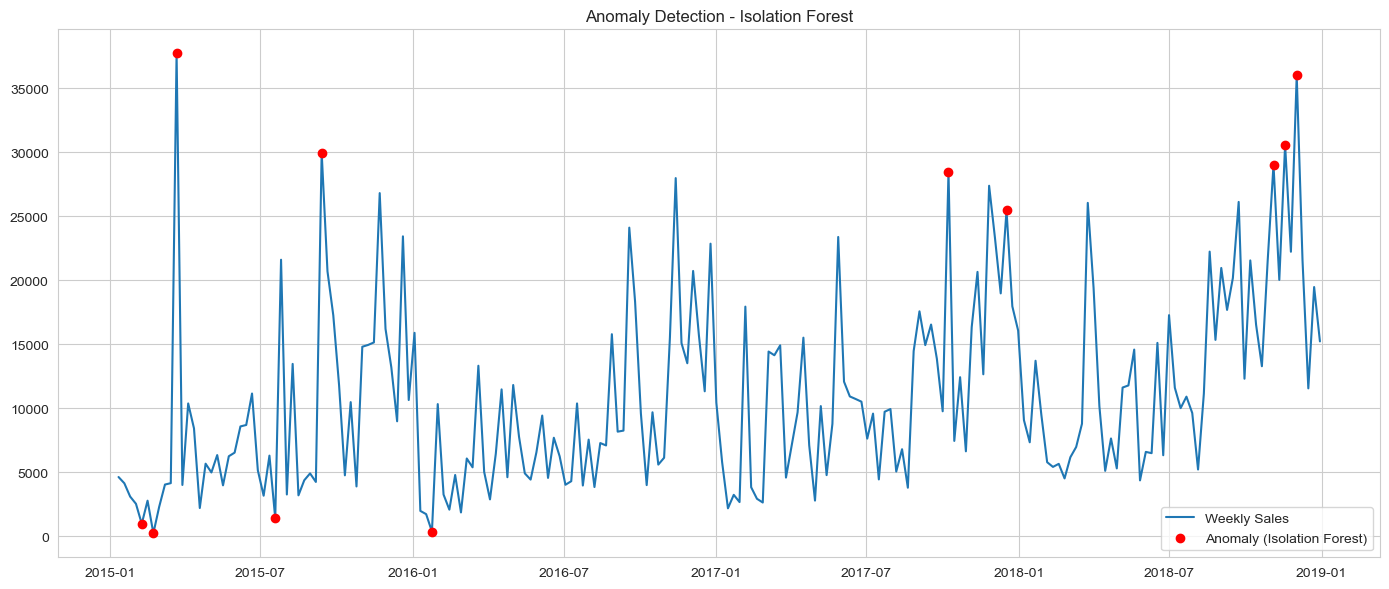

    Order Date      Sales
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
144 2017-10-08  28412.098
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


In [45]:
from sklearn.ensemble import IsolationForest

weekly = weekly_sales.copy()
weekly['SalesLag'] = weekly['Sales'].shift(1)
weekly.dropna(inplace=True)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly['anomaly_iso'] = iso_forest.fit_predict(weekly[['Sales']])
weekly['anomaly_iso'] = weekly['anomaly_iso'].map({1: 0, -1: 1})

plt.figure(figsize=(14,6))
plt.plot(weekly['Order Date'], weekly['Sales'], label='Weekly Sales')
anom = weekly[weekly['anomaly_iso']==1]
plt.scatter(anom['Order Date'], anom['Sales'], color='red', label='Anomaly (Isolation Forest)', zorder=5)
plt.legend()
plt.title('Anomaly Detection - Isolation Forest')
plt.tight_layout()
plt.savefig('charts/anomalies_isolation_forest.png')
plt.show()

print(anom[['Order Date','Sales']])

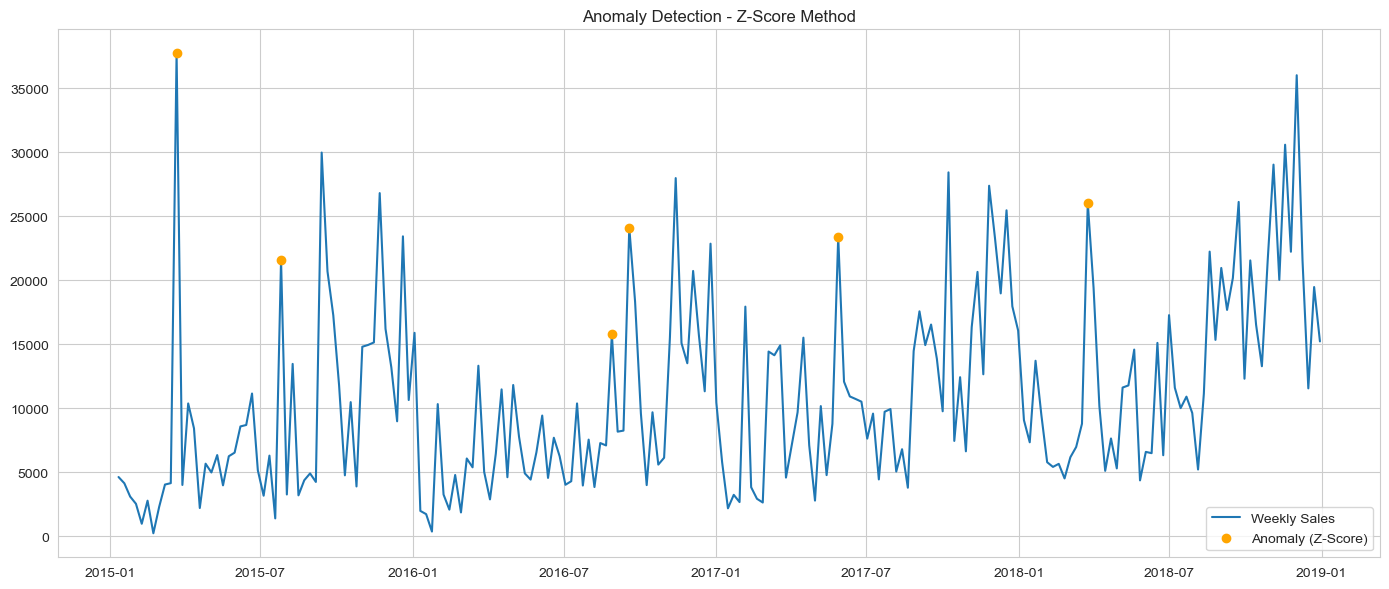

    Order Date      Sales    zscore
11  2015-03-22  37703.665  2.460650
29  2015-07-26  21590.080  2.136467
86  2016-08-28  15773.478  2.053924
89  2016-09-18  24095.960  2.122082
125 2017-05-28  23367.662  2.008225
168 2018-03-25  26029.904  2.435627


In [46]:
# Z-score based detection

weekly['rolling_mean'] = weekly['Sales'].rolling(window=8, min_periods=1).mean()
weekly['rolling_std'] = weekly['Sales'].rolling(window=8, min_periods=1).std()
weekly['zscore'] = (weekly['Sales'] - weekly['rolling_mean']) / weekly['rolling_std']
weekly['anomaly_zscore'] = (weekly['zscore'].abs() > 2).astype(int)

plt.figure(figsize=(14,6))
plt.plot(weekly['Order Date'], weekly['Sales'], label='Weekly Sales')
anom_z = weekly[weekly['anomaly_zscore']==1]
plt.scatter(anom_z['Order Date'], anom_z['Sales'], color='orange', label='Anomaly (Z-Score)', zorder=5)
plt.legend()
plt.title('Anomaly Detection - Z-Score Method')
plt.tight_layout()
plt.savefig('charts/anomalies_zscore.png')
plt.show()

print(anom_z[['Order Date','Sales','zscore']])

In [47]:
# Compare agreement between methods

agreement = (weekly['anomaly_iso'] == weekly['anomaly_zscore']).mean()
both_flagged = weekly[(weekly['anomaly_iso']==1) & (weekly['anomaly_zscore']==1)]
print(f"Agreement rate: {agreement*100:.1f}%")
print(f"\nWeeks flagged by BOTH methods:\n{both_flagged[['Order Date','Sales']]}")

Agreement rate: 92.8%

Weeks flagged by BOTH methods:
   Order Date      Sales
11 2015-03-22  37703.665


**TASK 6 — Product Demand Segmentation (Clustering)**

In [48]:
subcat_features = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales','sum'),
    Avg_Order_Value=('Sales','mean')
).reset_index()

# Year-over-year growth rate
yearly_subcat = df.groupby(['Sub-Category','Year'])['Sales'].sum().reset_index()
growth_rates = yearly_subcat.pivot(index='Sub-Category', columns='Year', values='Sales').pct_change(axis=1).mean(axis=1)
subcat_features['Growth_Rate'] = subcat_features['Sub-Category'].map(growth_rates)

# Volatility - std dev of monthly sales
monthly_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='M')])['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std()
subcat_features['Volatility'] = subcat_features['Sub-Category'].map(volatility)

subcat_features.dropna(inplace=True)
subcat_features

,Sub-Category,Total_Sales,Avg_Order_Value,Growth_Rate,Volatility
0,Accessories,164186.7000,217.178175,0.376381,2579.994809
1,Appliances,104618.4030,227.926804,0.399276,1821.621539
2,Art,26705.4100,34.019631,0.166056,330.488343
3,Binders,200028.7850,134.067550,0.218736,3848.223648
4,Bookcases,113813.1987,503.598224,0.238065,2220.405080
5,Chairs,322822.7310,531.833165,0.071358,4407.232960
6,Copiers,146248.0940,2215.880212,0.846718,5500.774391
7,Envelopes,16128.0460,65.032444,-0.027666,228.218688
8,Fasteners,3001.9600,14.027850,0.157034,48.742229
9,Furnishings,89212.0180,95.823865,0.287889,1360.017867


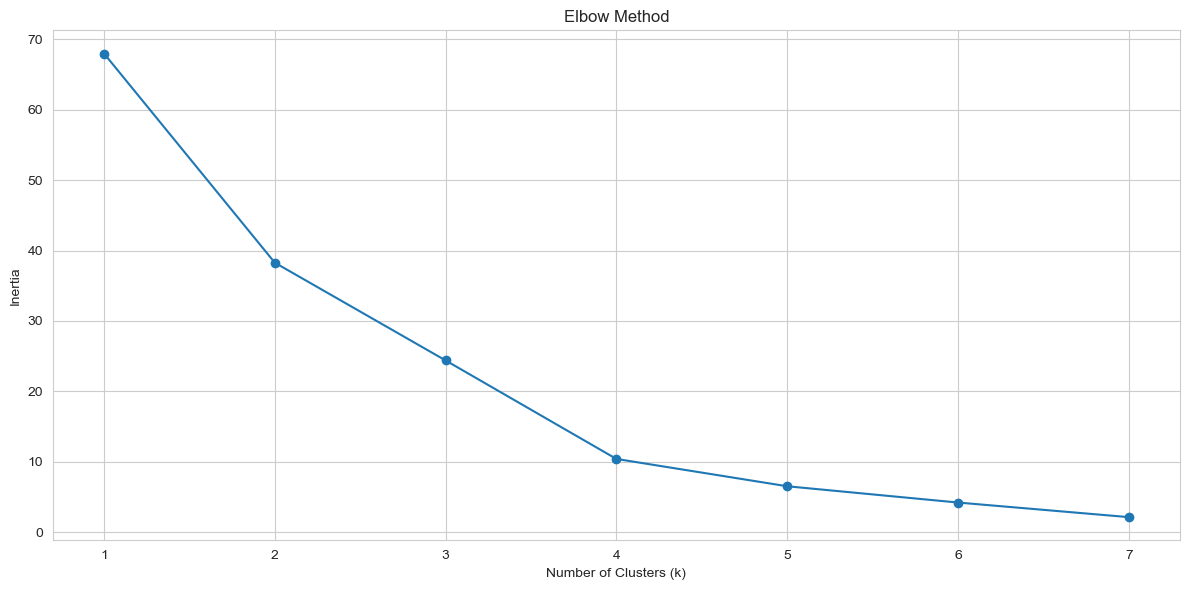

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['Total_Sales','Growth_Rate','Volatility','Avg_Order_Value']
X_cluster = subcat_features[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.savefig('charts/elbow_method.png')
plt.show()

In [50]:
# Fit final KMeans (pick k from elbow, e.g. 4)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters based on characteristics
cluster_summary = subcat_features.groupby('Cluster')[features].mean()
print(cluster_summary)

           Total_Sales  Growth_Rate   Volatility  Avg_Order_Value
Cluster                                                          
0        167743.362500     0.463389  5552.164569      1930.716763
1         55331.883212     0.199589   907.223743       129.054568
2        239495.780667     0.180965  3489.056075       361.131228
3         46420.308000     1.928448  2025.094139       252.284283


In [55]:
cluster_labels = {
    0: 'High Value, Volatile Demand',
    1: 'Low Volume, Stable Demand',
    2: 'High Volume, Stable Demand',
    3: 'Niche, Rapidly Growing'
}
subcat_features['Cluster_Label'] = subcat_features['Cluster'].map(cluster_labels)
subcat_features[['Sub-Category','Cluster','Cluster_Label']]

,Sub-Category,Cluster,Cluster_Label
0,Accessories,2,"High Volume, Stable Demand"
1,Appliances,1,"Low Volume, Stable Demand"
2,Art,1,"Low Volume, Stable Demand"
3,Binders,2,"High Volume, Stable Demand"
4,Bookcases,1,"Low Volume, Stable Demand"
5,Chairs,2,"High Volume, Stable Demand"
6,Copiers,0,"High Value, Volatile Demand"
7,Envelopes,1,"Low Volume, Stable Demand"
8,Fasteners,1,"Low Volume, Stable Demand"
9,Furnishings,1,"Low Volume, Stable Demand"


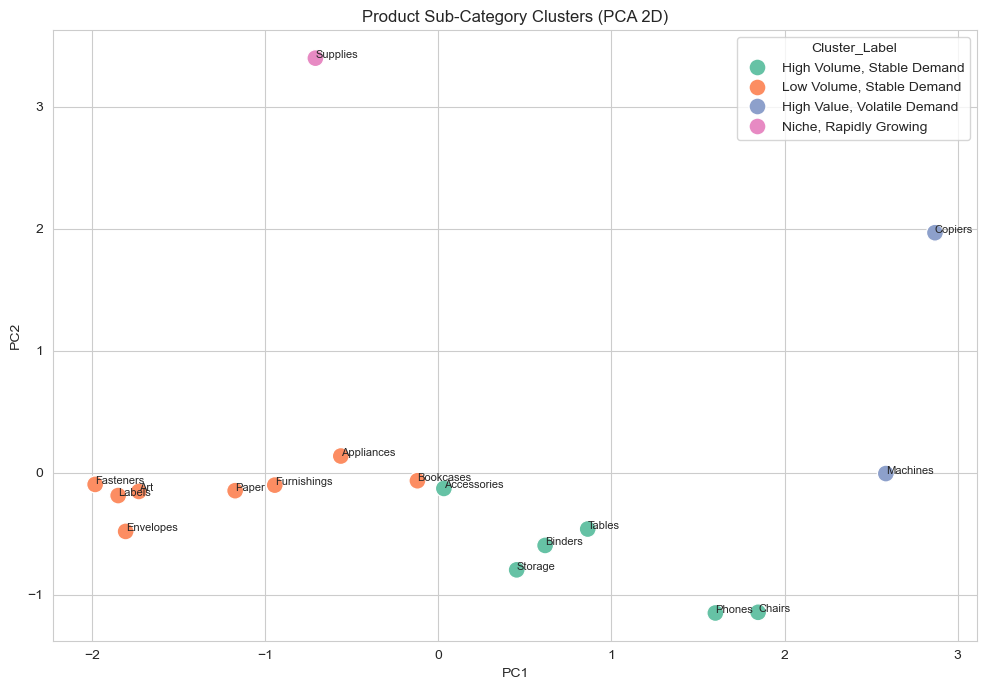

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
subcat_features['PC1'] = X_pca[:,0]
subcat_features['PC2'] = X_pca[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(data=subcat_features, x='PC1', y='PC2', hue='Cluster_Label', s=150, palette='Set2')
for i, row in subcat_features.iterrows():
    plt.annotate(row['Sub-Category'], (row['PC1'], row['PC2']), fontsize=8)
plt.title('Product Sub-Category Clusters (PCA 2D)')
plt.tight_layout()
plt.savefig('charts/clustering_pca.png')
plt.show()

**TASK 7 — Streamlit Dashboard**

In [57]:
import os

project_path = r"C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita"

# Create .streamlit folder INSIDE the project folder (note the separate / before .streamlit)
os.makedirs(os.path.join(project_path, ".streamlit"), exist_ok=True)

theme_config = '''[theme]
base="light"
primaryColor="#1F4E5F"
backgroundColor="#FFFFFF"
secondaryBackgroundColor="#EAF1F4"
textColor="#262730"
font="sans serif"
'''

with open(os.path.join(project_path, ".streamlit", "config.toml"), "w") as f:
    f.write(theme_config)

# Write the upgraded app.py
app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

st.set_page_config(page_title="Sales Forecasting Dashboard", layout="wide", page_icon="\U0001F4CA")

st.markdown("""
<style>
.stApp { background-color: #FFFFFF; }
[data-testid="stSidebar"] { background-color: #EAF1F4; }
div[data-testid="stMetric"] {
    background-color: #F7FAFB;
    border: 1px solid #D9E4E8;
    border-radius: 10px;
    padding: 12px 16px;
}
h1, h2, h3 { color: #1F4E5F; }
.insight-box {
    background-color: #F7FAFB;
    border-left: 4px solid #1F4E5F;
    padding: 12px 16px;
    border-radius: 6px;
    margin-bottom: 12px;
}
</style>
""", unsafe_allow_html=True)

@st.cache_data
def load_data():
    df = pd.read_csv("train.csv", encoding="latin1")
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
    df["Year"] = df["Order Date"].dt.year
    df["Month"] = df["Order Date"].dt.month
    return df

df = load_data()

st.sidebar.title("Sales Intelligence")
st.sidebar.caption("Superstore Forecasting & Demand System")
page = st.sidebar.radio("Navigate", ["Sales Overview", "Forecast Explorer", "Anomaly Report", "Demand Segments"])
st.sidebar.markdown("---")
st.sidebar.caption(f"Data range: {df['Order Date'].min().date()} -> {df['Order Date'].max().date()}")
st.sidebar.caption(f"Total records: {len(df):,}")

if page == "Sales Overview":
    st.title("Sales Overview Dashboard")

    col1, col2, col3 = st.columns(3)
    with col1:
        region_filter = st.multiselect("Region", df["Region"].unique(), default=list(df["Region"].unique()))
    with col2:
        category_filter = st.multiselect("Category", df["Category"].unique(), default=list(df["Category"].unique()))
    with col3:
        date_range = st.date_input("Date range", [df["Order Date"].min(), df["Order Date"].max()])

    filtered = df[
        df["Region"].isin(region_filter) &
        df["Category"].isin(category_filter) &
        (df["Order Date"] >= pd.to_datetime(date_range[0])) &
        (df["Order Date"] <= pd.to_datetime(date_range[1]))
    ]

    total_sales = filtered["Sales"].sum()
    total_orders = filtered["Order ID"].nunique()
    avg_order_value = filtered.groupby("Order ID")["Sales"].sum().mean()
    years = sorted(filtered["Year"].unique())
    yoy = None
    if len(years) >= 2:
        last, prev = filtered[filtered["Year"]==years[-1]]["Sales"].sum(), filtered[filtered["Year"]==years[-2]]["Sales"].sum()
        yoy = ((last - prev) / prev) * 100 if prev else None

    k1, k2, k3, k4 = st.columns(4)
    k1.metric("Total Sales", f"${total_sales:,.0f}")
    k2.metric("Total Orders", f"{total_orders:,}")
    k3.metric("Avg Order Value", f"${avg_order_value:,.2f}")
    k4.metric("YoY Growth", f"{yoy:.1f}%" if yoy is not None else "N/A")

    st.markdown("---")

    c1, c2 = st.columns([1,1])
    with c1:
        yearly_sales = filtered.groupby("Year")["Sales"].sum().reset_index()
        fig1 = px.bar(yearly_sales, x="Year", y="Sales", title="Total Sales by Year",
                      color_discrete_sequence=["#1F4E5F"])
        st.plotly_chart(fig1, use_container_width=True)
    with c2:
        monthly = filtered.set_index("Order Date")["Sales"].resample("M").sum().reset_index()
        fig2 = px.line(monthly, x="Order Date", y="Sales", title="Monthly Sales Trend",
                       color_discrete_sequence=["#1F4E5F"])
        st.plotly_chart(fig2, use_container_width=True)

    c3, c4 = st.columns(2)
    with c3:
        reg_sales = filtered.groupby("Region")["Sales"].sum().reset_index()
        fig3 = px.pie(reg_sales, names="Region", values="Sales", title="Sales by Region",
                      color_discrete_sequence=px.colors.sequential.Teal)
        st.plotly_chart(fig3, use_container_width=True)
    with c4:
        cat_sales = filtered.groupby("Category")["Sales"].sum().reset_index()
        fig4 = px.pie(cat_sales, names="Category", values="Sales", title="Sales by Category",
                      color_discrete_sequence=px.colors.sequential.Teal)
        st.plotly_chart(fig4, use_container_width=True)

    st.subheader("Top 10 Sub-Categories by Revenue")
    top10 = filtered.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()
    st.dataframe(top10, use_container_width=True)

    st.download_button("Download filtered data as CSV",
                        filtered.to_csv(index=False).encode("utf-8"),
                        "filtered_sales_data.csv", "text/csv")

elif page == "Forecast Explorer":
    st.title("Forecast Explorer")

    dim = st.selectbox("Select dimension", ["Category", "Region"])
    options = df[dim].unique()
    choice = st.selectbox(f"Select {dim}", options)
    horizon = st.slider("Forecast horizon (months)", 1, 3, 3)

    sub = df[df[dim] == choice]
    ts = sub.set_index("Order Date")["Sales"].resample("M").sum().reset_index()
    ts["Lag1"] = ts["Sales"].shift(1)
    ts["Lag2"] = ts["Sales"].shift(2)
    ts["Lag3"] = ts["Sales"].shift(3)
    ts["RollingMean3"] = ts["Sales"].shift(1).rolling(3).mean()
    ts["Month"] = ts["Order Date"].dt.month
    ts["Quarter"] = ts["Order Date"].dt.quarter
    ts.dropna(inplace=True)

    feats = ["Lag1","Lag2","Lag3","RollingMean3","Month","Quarter"]
    X, y = ts[feats], ts["Sales"]
    Xtr, Xte, ytr, yte = X.iloc[:-3], X.iloc[-3:], y.iloc[:-3], y.iloc[-3:]

    with st.spinner("Training forecast model..."):
        model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)[:horizon]

    mae = mean_absolute_error(yte[:horizon], pred)
    rmse = np.sqrt(mean_squared_error(yte[:horizon], pred))

    fig = px.line(ts.tail(15), x="Order Date", y="Sales", title=f"Forecast for {choice}",
                  color_discrete_sequence=["#1F4E5F"])
    future_dates = ts["Order Date"].iloc[-3:-3+horizon] if horizon < 3 else ts["Order Date"].iloc[-3:]
    fig.add_scatter(x=future_dates, y=pred, mode="lines+markers", name="Forecast",
                     line=dict(dash="dash", color="#D97706"))
    st.plotly_chart(fig, use_container_width=True)

    m1, m2 = st.columns(2)
    m1.metric("MAE", f"{mae:.2f}")
    m2.metric("RMSE", f"{rmse:.2f}")

    forecast_str = ", ".join(f"${v:,.0f}" for v in pred)
    st.markdown(f"""
    <div class="insight-box">
    Forecast for <b>{choice}</b>: over the next {horizon} month(s), predicted sales are {forecast_str}.
    </div>
    """, unsafe_allow_html=True)

    forecast_table = pd.DataFrame({
        "Month": [f"Month {i+1}" for i in range(len(pred))],
        "Forecasted Sales": pred
    })
    st.download_button("Download forecast as CSV",
                        forecast_table.to_csv(index=False).encode("utf-8"),
                        f"forecast_{choice}.csv", "text/csv")

elif page == "Anomaly Report":
    st.title("Anomaly Report")

    weekly = df.set_index("Order Date")["Sales"].resample("W").sum().reset_index()
    iso = IsolationForest(contamination=0.05, random_state=42)
    weekly["anomaly"] = iso.fit_predict(weekly[["Sales"]])
    weekly["anomaly"] = weekly["anomaly"].map({1: 0, -1: 1})
    anom = weekly[weekly["anomaly"]==1]

    k1, k2 = st.columns(2)
    k1.metric("Anomalous Weeks Detected", len(anom))
    k2.metric("% of Total Weeks", f"{len(anom)/len(weekly)*100:.1f}%")

    fig = px.line(weekly, x="Order Date", y="Sales", title="Weekly Sales with Anomalies Highlighted",
                  color_discrete_sequence=["#1F4E5F"])
    fig.add_scatter(x=anom["Order Date"], y=anom["Sales"], mode="markers",
                     marker=dict(color="#D97706", size=10), name="Anomaly")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Detected Anomalies")
    st.dataframe(anom[["Order Date","Sales"]].reset_index(drop=True), use_container_width=True)

    st.download_button("Download anomaly list as CSV",
                        anom.to_csv(index=False).encode("utf-8"),
                        "anomalies.csv", "text/csv")

elif page == "Demand Segments":
    st.title("Product Demand Segments")

    subcat = df.groupby("Sub-Category").agg(Total_Sales=("Sales","sum"), Avg_Order_Value=("Sales","mean")).reset_index()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subcat[["Total_Sales","Avg_Order_Value"]])
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    subcat["Cluster"] = km.fit_predict(X_scaled)

    label_map = {0: "High Value, Volatile Demand", 1: "Low Volume, Stable Demand", 2: "High Volume, Stable Demand", 3: "Niche, Rapidly Growing"}
    subcat["Cluster_Label"] = subcat["Cluster"].map(label_map)

    fig = px.scatter(subcat, x="Total_Sales", y="Avg_Order_Value", color="Cluster_Label",
                      hover_data=["Sub-Category"], title="Product Clusters",
                      color_discrete_sequence=px.colors.qualitative.Set2)
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Sub-Category to Cluster Mapping")
    selected_cluster = st.selectbox("Filter by cluster", ["All"] + list(subcat["Cluster_Label"].unique()))
    display_df = subcat if selected_cluster == "All" else subcat[subcat["Cluster_Label"]==selected_cluster]
    st.dataframe(display_df[["Sub-Category","Cluster_Label","Total_Sales","Avg_Order_Value"]], use_container_width=True)

    st.download_button("Download cluster mapping as CSV",
                        subcat.to_csv(index=False).encode("utf-8"),
                        "product_clusters.csv", "text/csv")
'''

with open(os.path.join(project_path, "app.py"), "w", encoding="utf-8") as f:
    f.write(app_code)

print("Both files written successfully:")
print("-", os.path.join(project_path, ".streamlit", "config.toml"))
print("-", os.path.join(project_path, "app.py"))

Both files written successfully:
- C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita\.streamlit\config.toml
- C:/Users/Pranita Kumbhar/Downloads/SalesForecasting_Pranita\app.py
